# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

---

## K-means Run

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

import warnings
warnings.filterwarnings("ignore")

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    # NUV-r
    # W1-W3

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

##############################################################
Removed 4958/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################
IQR clipping (k=1.5): Removing an additional 522/1822 outliers (28.6%)
Remaining galaxies: 1300


A copy of unscaled/scaled galaxy features was written to data/kmeans_feature_data.csv!

#######################################################
Using default feature list for feature raincloud plots.
#######################################################
#######################################
Incoming...expect an output of 9 plots.
#######################################


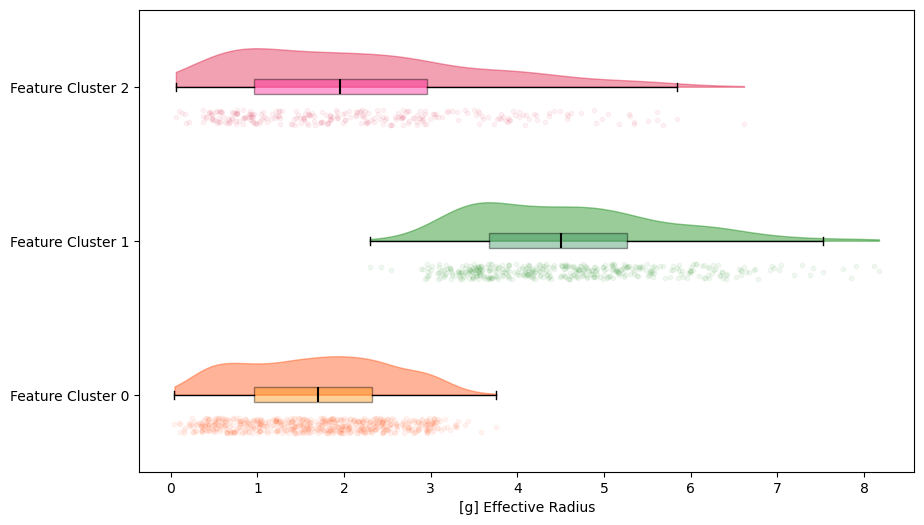

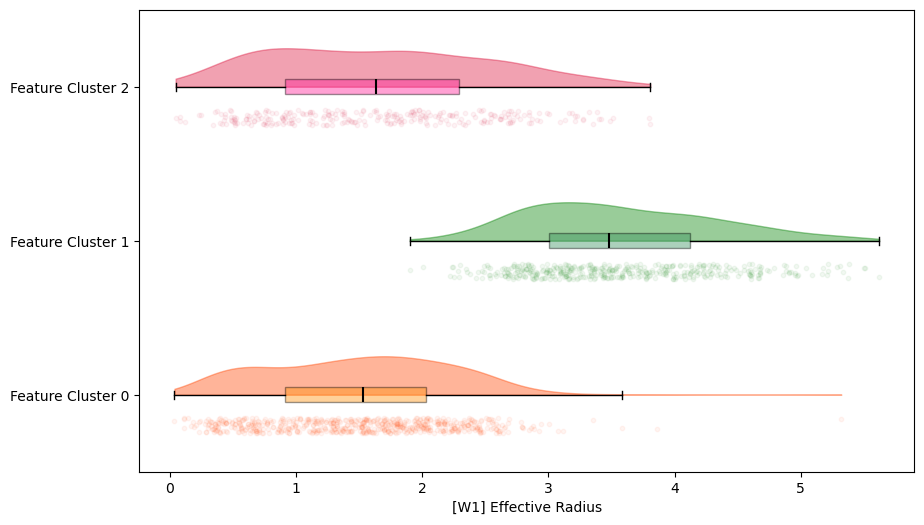

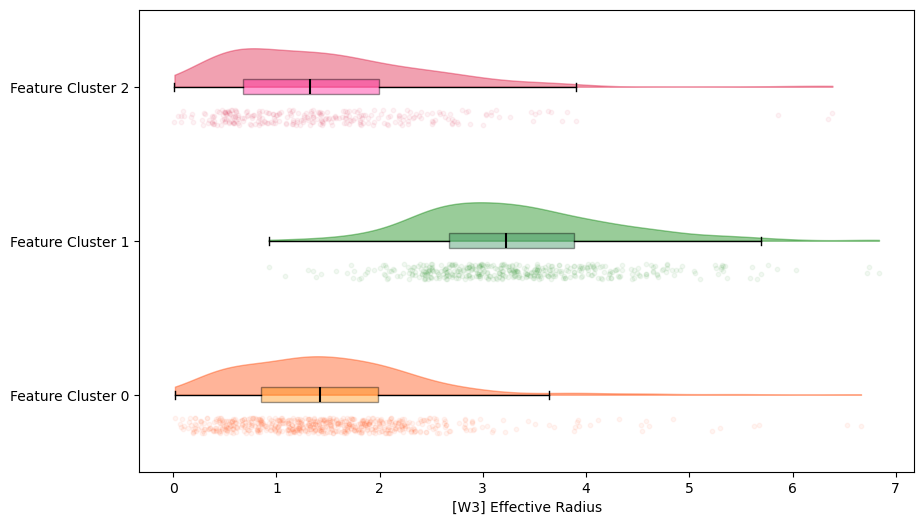

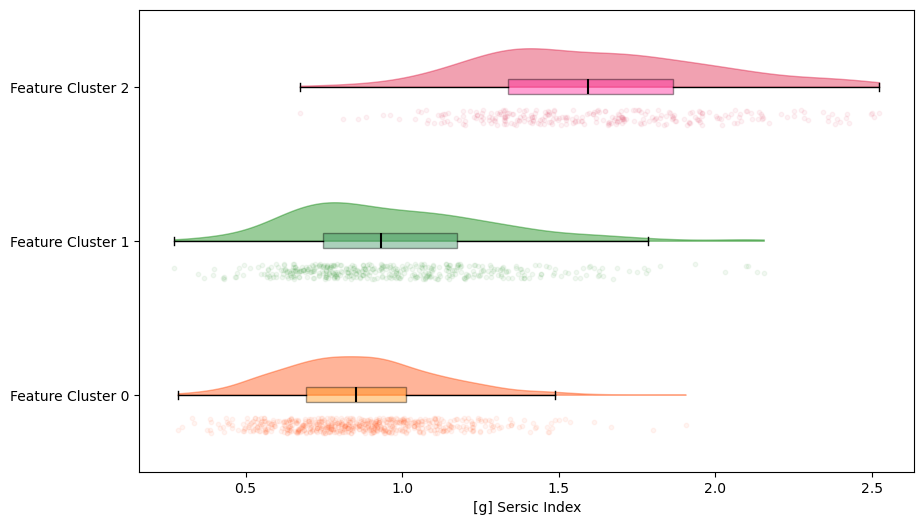

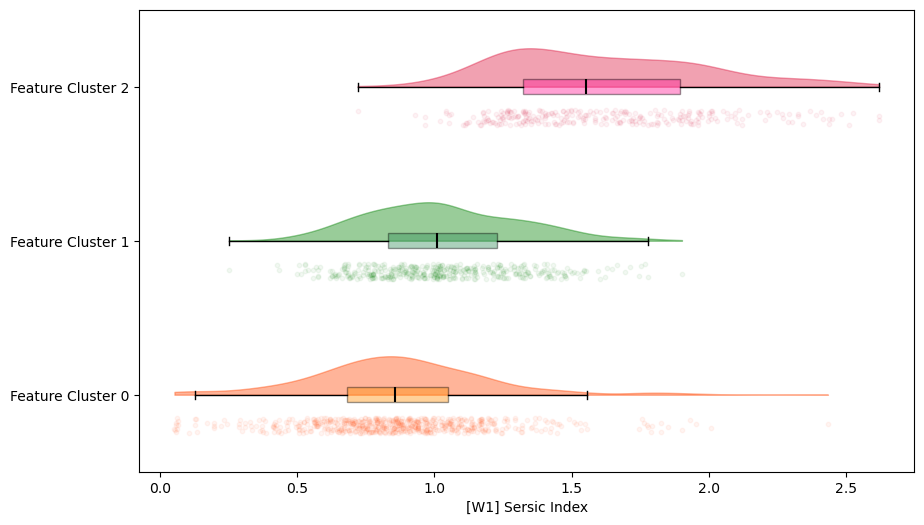

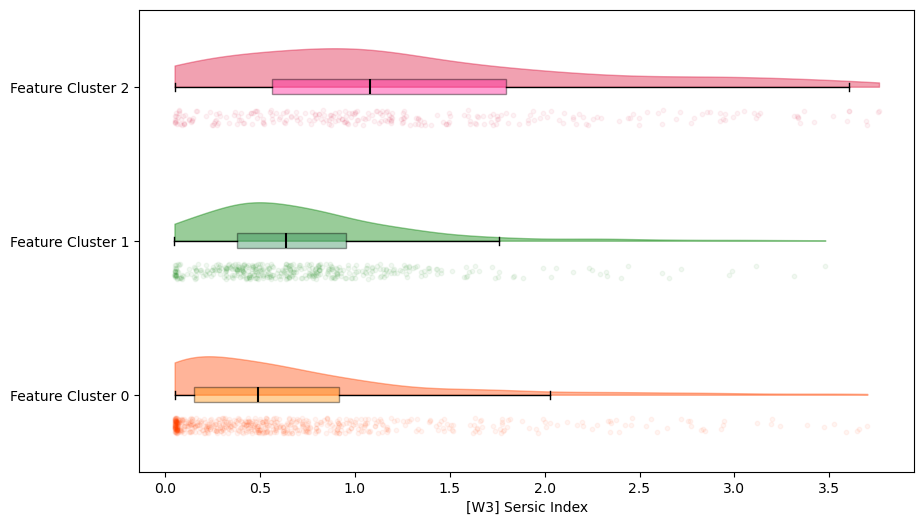

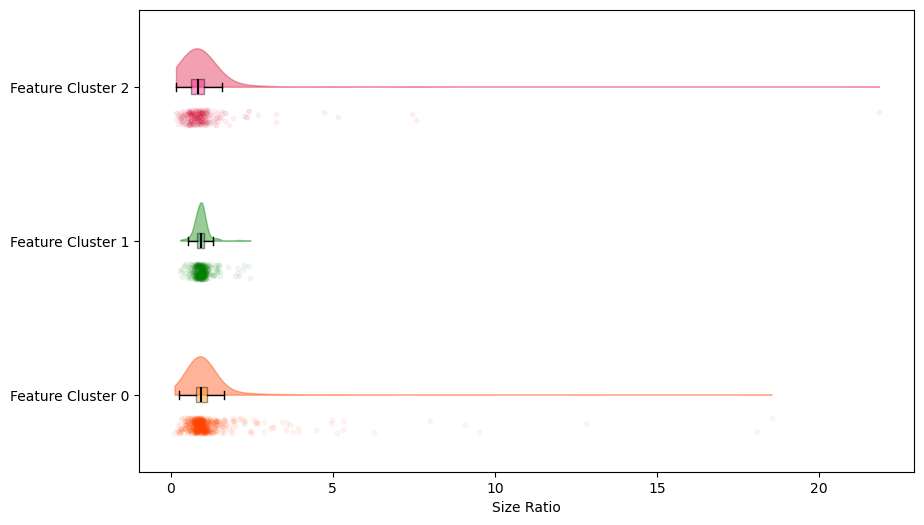

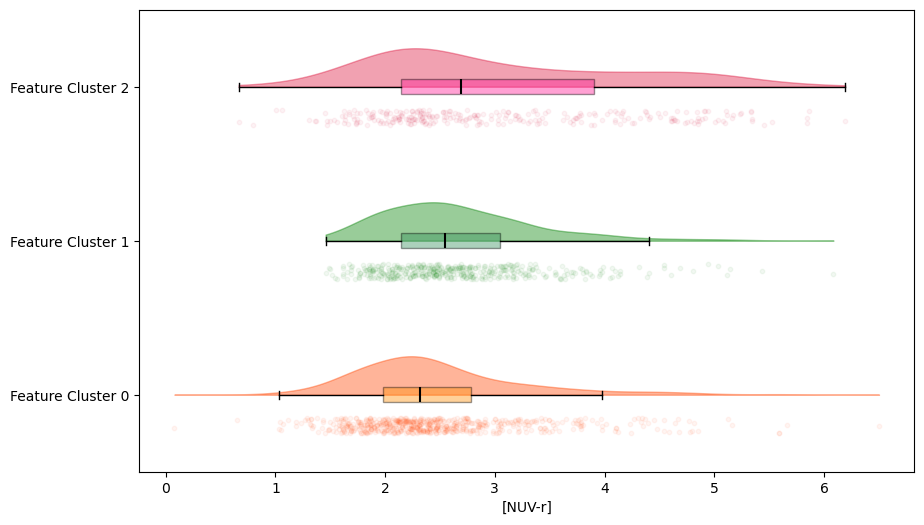

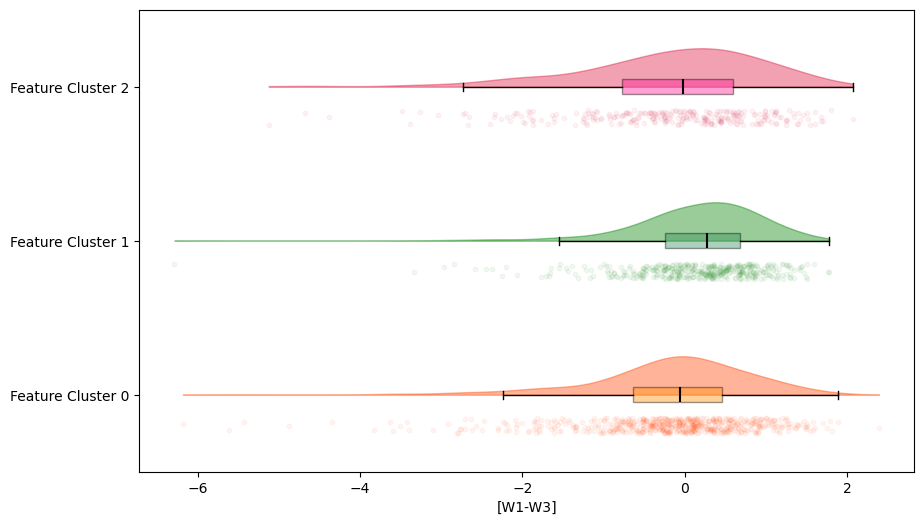

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/kmeans_median_features.csv:

##################################################################
Using default layout dictionary for median group feature subplots!
##################################################################


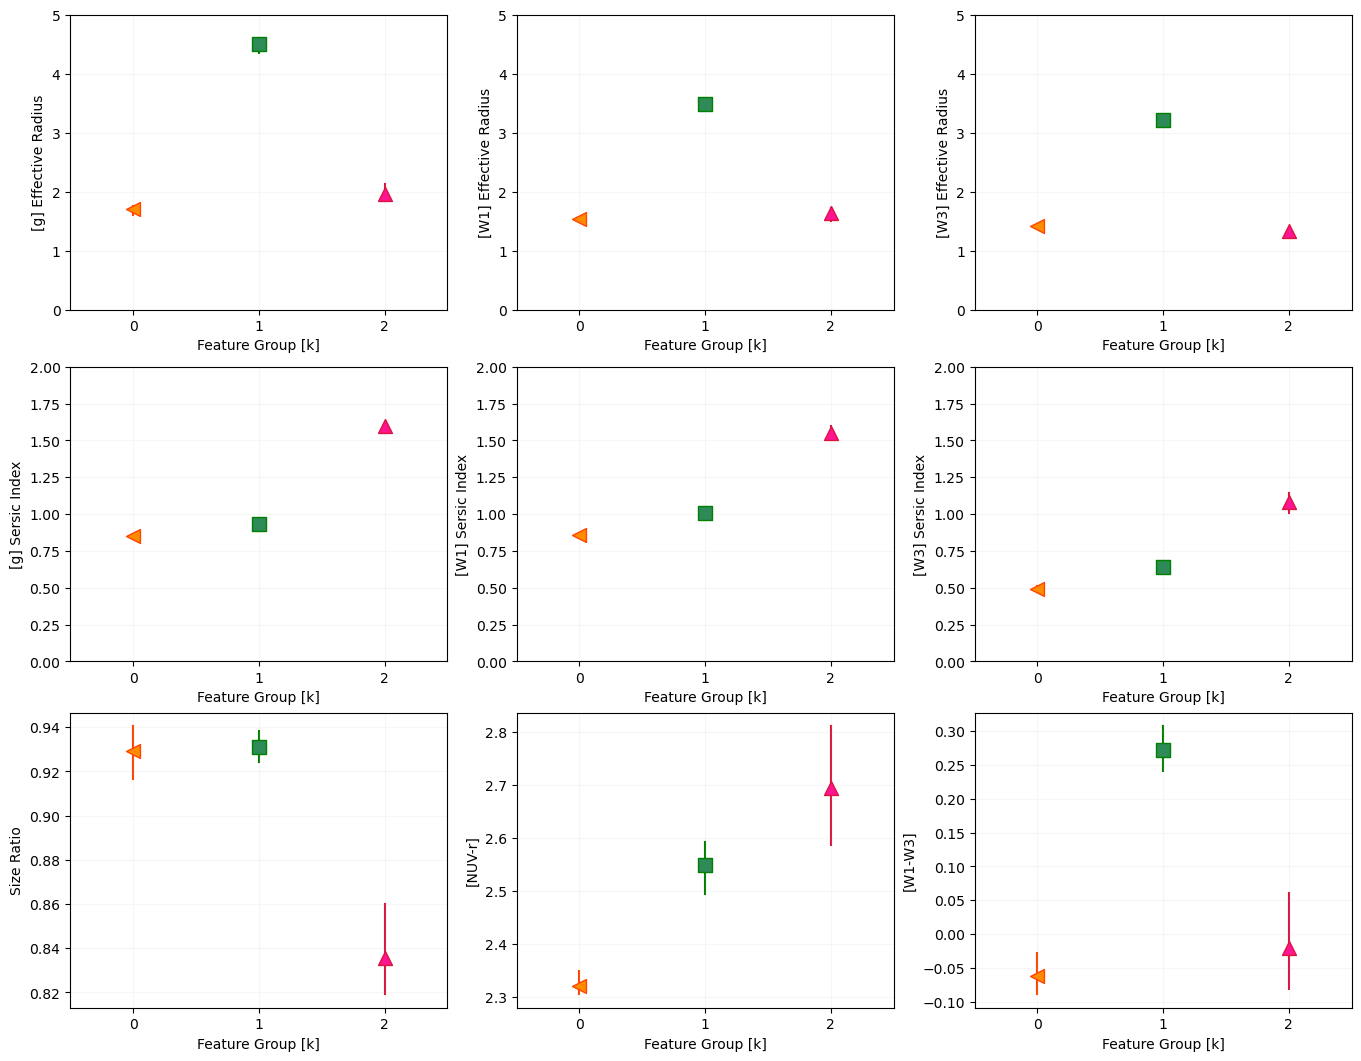

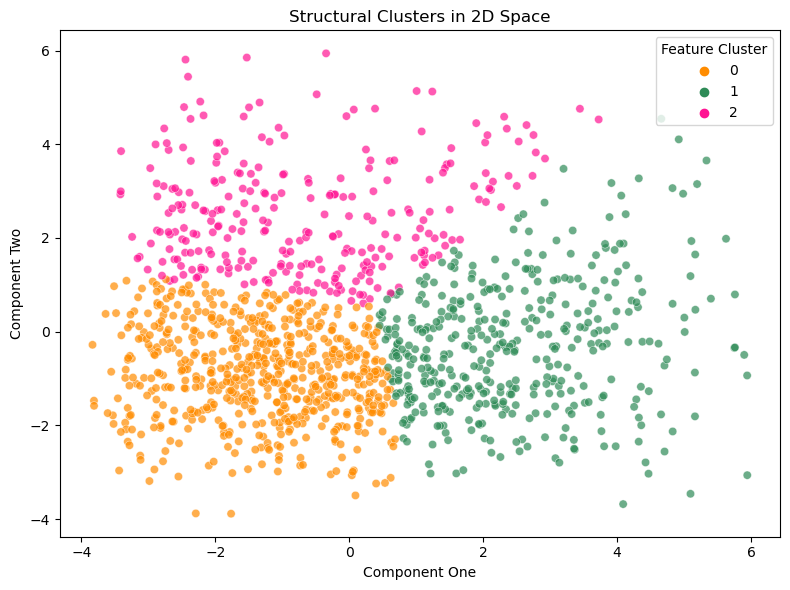

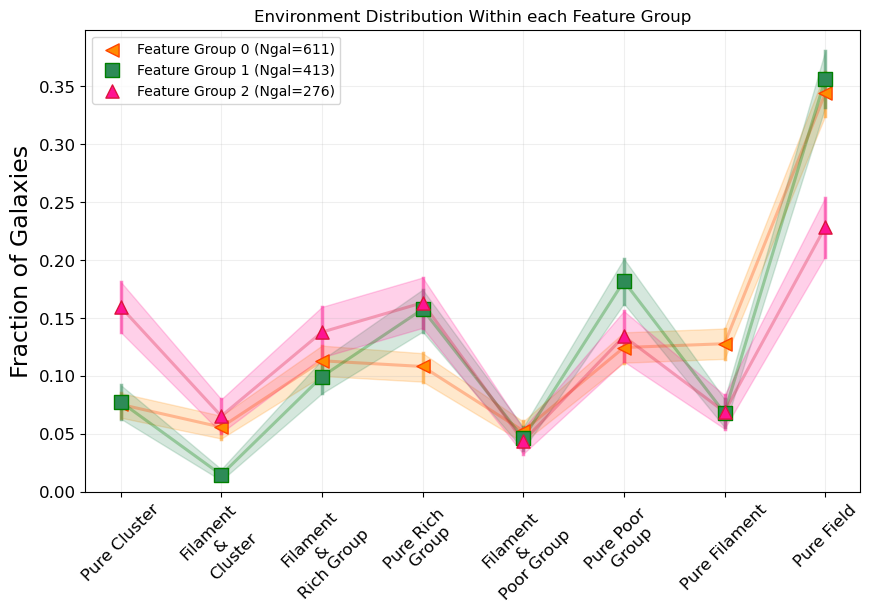

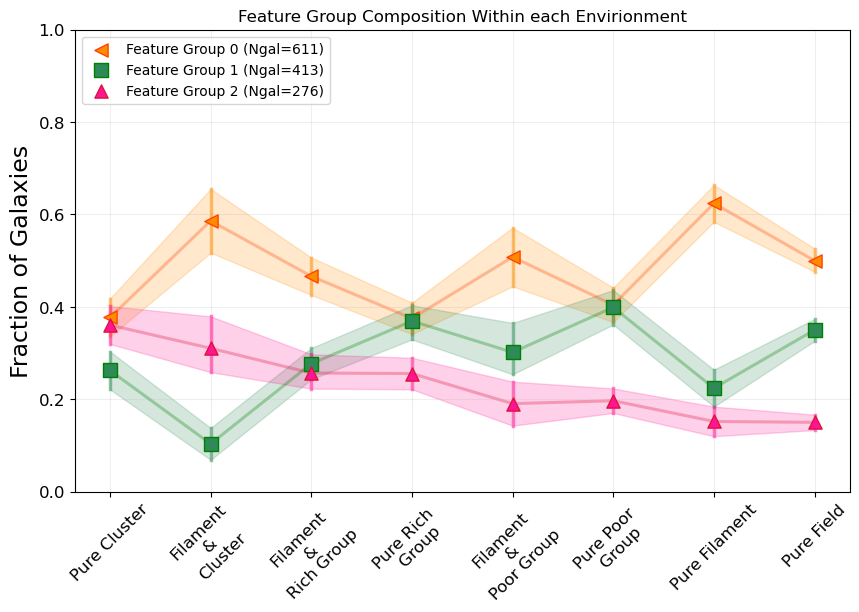

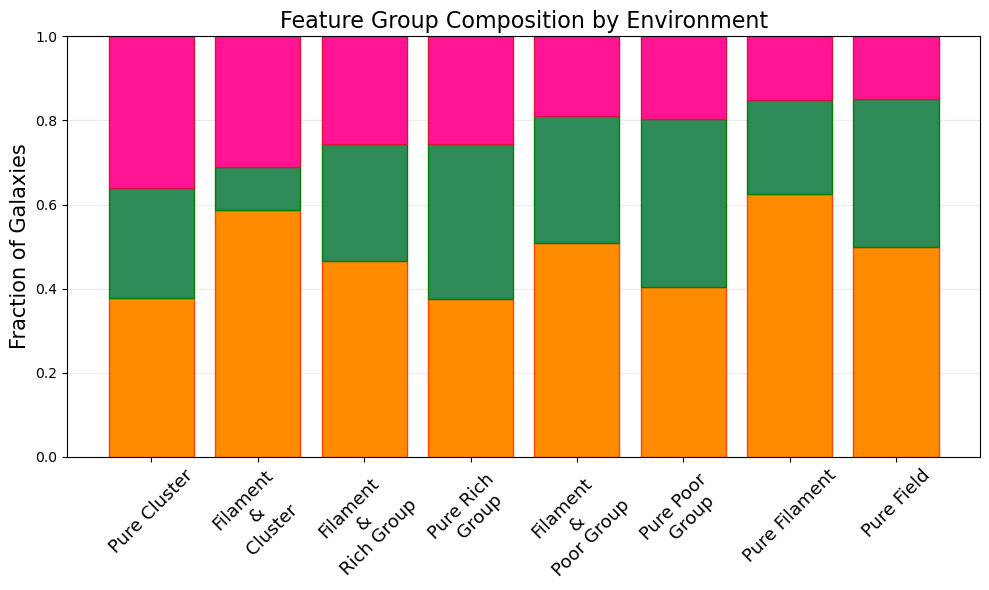

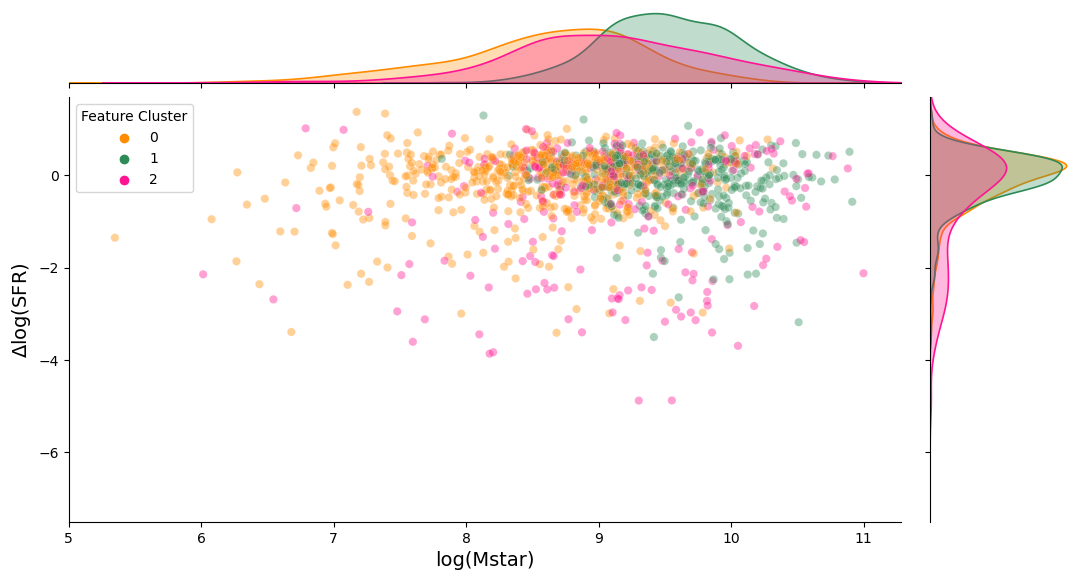

In [35]:
df = run_kmeans(colors=False)

## HDBSCAN Run

In [1]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

##############################################################
Removed 4785/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################


A copy of the scaled galaxy features was written to data/hdb_feature_data.csv!

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/hdbscan_median_features.csv:

##################################################################
Using default layout dictionary for median group feature subplots!
##################################################################


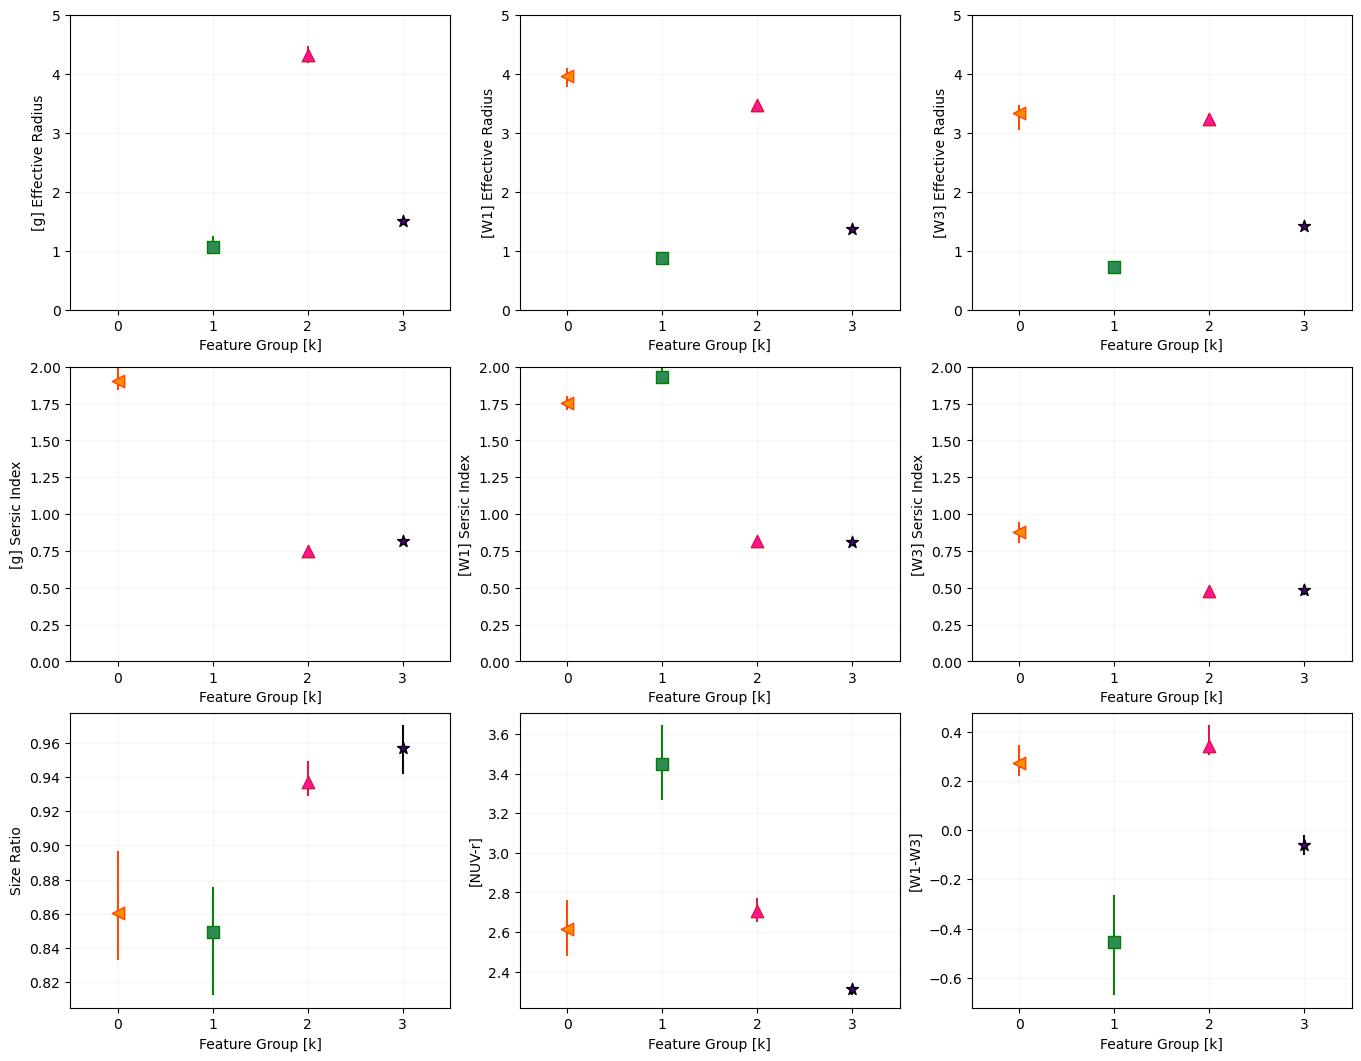

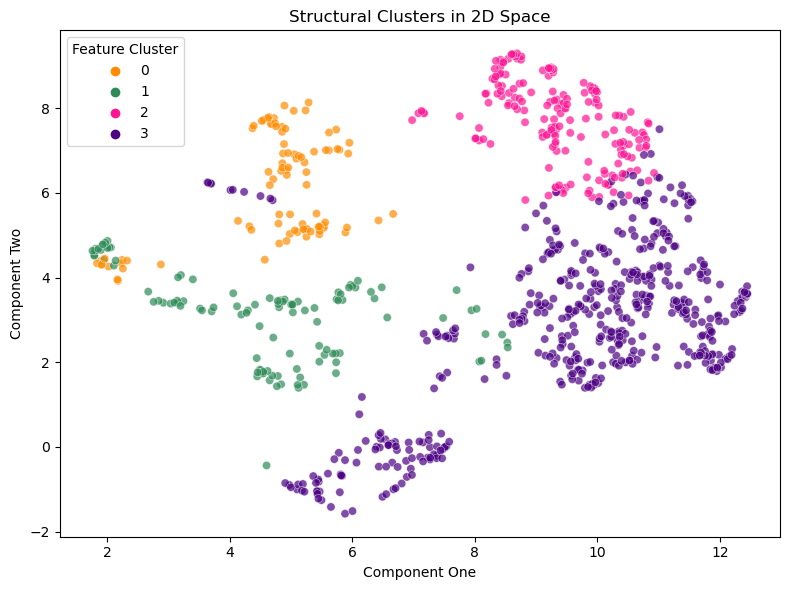

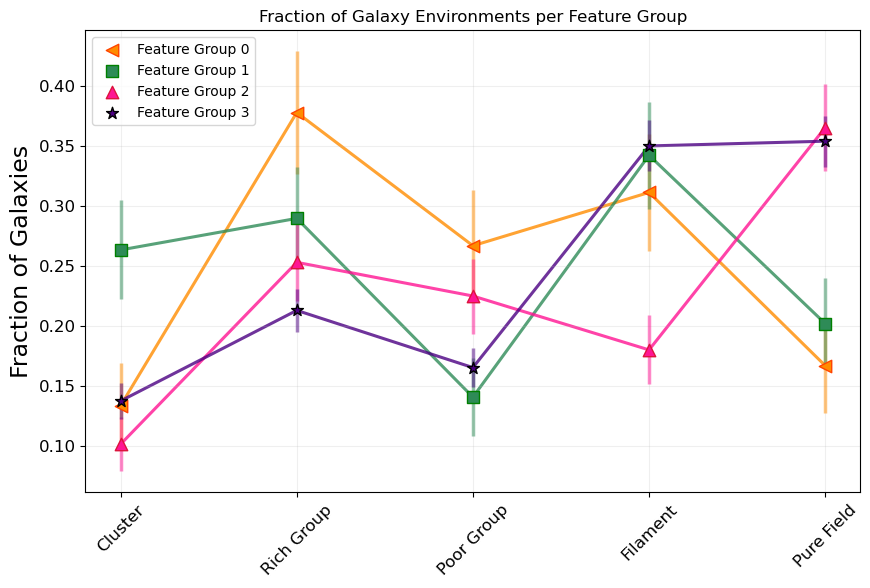

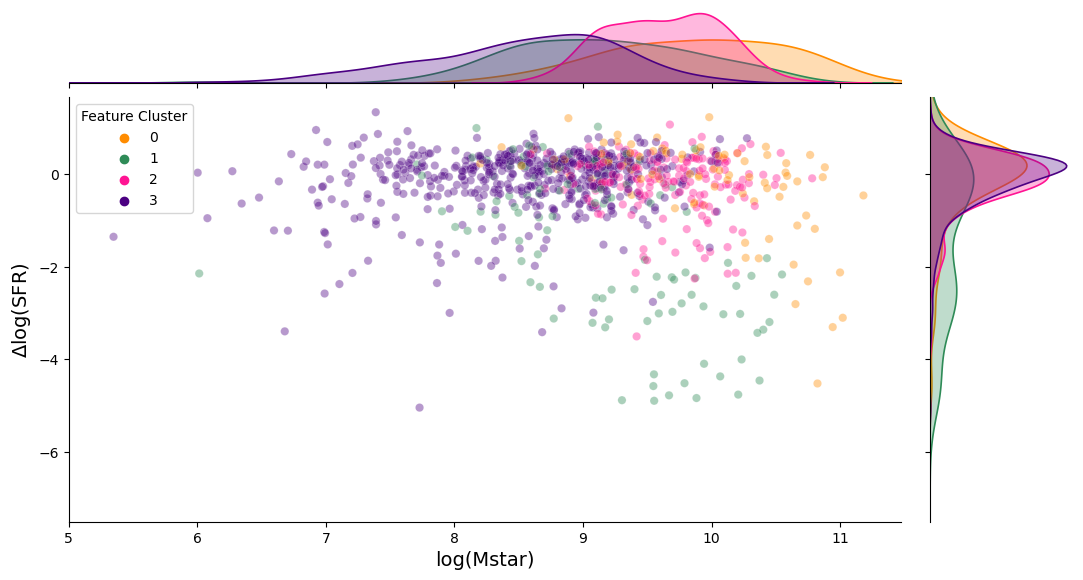

In [2]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan(colors=False)

## Testbed

In [53]:
df.columns

Index(['CXC_g', 'CRE_g', 'CN_g', 'CNumerical_Error_g', 'CXC_r', 'CRE_r',
       'CN_r', 'CNumerical_Error_r', 'CXC_W1-fixBA', 'CRE_W1-fixBA',
       'CN_W1-fixBA', 'CNumerical_Error_W1-fixBA', 'CXC_W2', 'CRE_W2', 'CN_W2',
       'CNumerical_Error_W2', 'CXC_W3-fixBA', 'CRE_W3-fixBA', 'CN_W3-fixBA',
       'CNumerical_Error_W3-fixBA', 'Vcosmic', 'logmstar', 'logsfr',
       'delta_logsfr', 'Size Ratio', 'NUV_r', 'W1_W3', 'cluster_member',
       'rich_group_memb', 'poor_group_memb', 'filament_member', 'pure_field',
       'CRE_g_unscaled', 'CRE_r_unscaled', 'CRE_W1-fixBA_unscaled',
       'CRE_W2_unscaled', 'CRE_W3-fixBA_unscaled', 'CN_g_unscaled',
       'CN_r_unscaled', 'CN_W1-fixBA_unscaled', 'CN_W2_unscaled',
       'CN_W3-fixBA_unscaled', 'Feature Cluster', 'Comp1', 'Comp2'],
      dtype='object')

In [30]:
#raincloud plots -- for each feature group, want to plot certain features, size ratio, and colors

#will begin with Size Ratio for FC0, FC1, FC2

from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

In [31]:
def marker_palette(feature_data):
    
    shapes = ['<', 's', '^', '*', 'D', 'v', 'X', '<', 'h', '>']
        
    try:
        clusters = feature_data['Feature Cluster'].unique()
        k = len(clusters)  #number of feature groups
        noise_flag = (-1 in clusters)
        k = k-1 if noise_flag else k
    except:
        k = len(feature_data)  #also number of feature groups --> for one row per feature group
                               #only needed if plotting medians
    
    if k == 3:
        cluster_colors = ['darkorange','seagreen','deeppink']
        edge_colors = ['orangered', 'green', 'crimson']
        
    elif k == 4:
        cluster_colors = ['darkorange','seagreen','deeppink','indigo']
        edge_colors = ['orangered', 'green', 'crimson', 'black']
    
    else:
        print(k, 'clusters')
        cluster_colors = sns.color_palette('husl', len(feature_data['Feature Cluster'].unique()))
        edge_colors = cluster_colors
    
    marker_shapes = [shapes[i % len(shapes)] for i in range(k)]
    
    if -1 in feature_data['Feature Cluster'].unique():
        cluster_colors.insert(0, 'lightgray')
        edge_colors.insert(0, 'darkgray')
        marker_shapes.insert(0, 'o')
    
    return cluster_colors, edge_colors, marker_shapes

# galaxies with Size Ratio > 4: 
     FC0=23, FC1=0, FC2=7


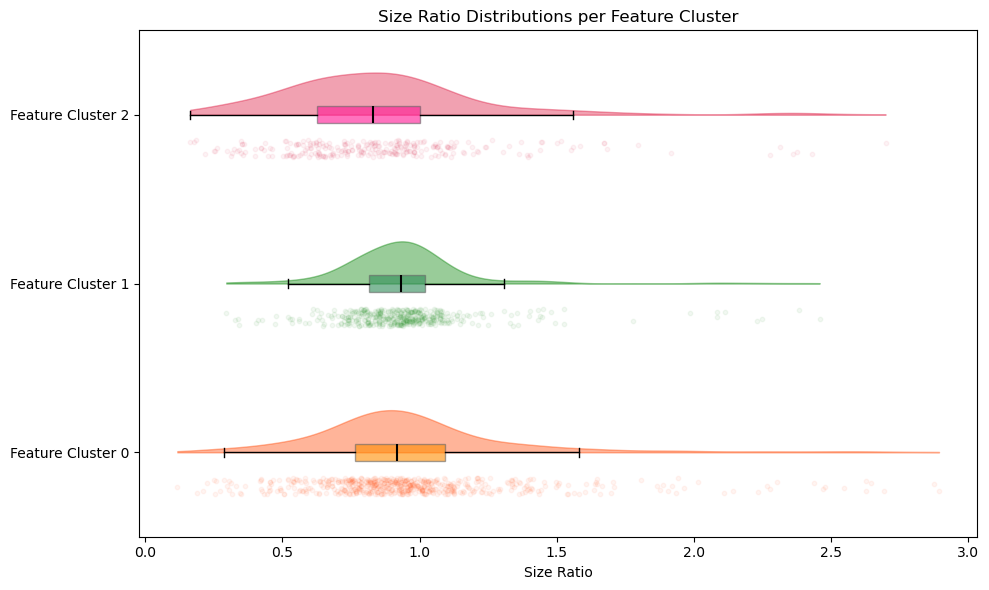

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

color_map, edge_map, marker_map = marker_palette(df)

data_x = [df['Size Ratio'][df['Feature Cluster'] == 0].dropna().values,
          df['Size Ratio'][df['Feature Cluster'] == 1].dropna().values,
          df['Size Ratio'][df['Feature Cluster'] == 2].dropna().values]

outliers=[len(data[data>3]) for data in data_x]
data_x = [data[data<3] for data in data_x]

# --- Boxplot (suppress fliers so they don't become "black circles") ---
bp = ax.boxplot(data_x, patch_artist=True, vert=False,
                showfliers=False,
                medianprops=dict(color='k', linewidth=1.5),
                widths=0.1)

for patch, color in zip(bp['boxes'], color_map):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('0.4')

# --- Violinplot (density) ---
vp = ax.violinplot(
    data_x, points=300,
    showmeans=False, showextrema=False, showmedians=False,
    vert=False
)

for i, b in enumerate(vp['bodies']):
    # clip violin to upper half in y-direction (raincloud "cloud")
    yvals = b.get_paths()[0].vertices[:, 1]
    b.get_paths()[0].vertices[:, 1] = np.clip(yvals, i+1, i+1.6)

    b.set_color(edge_map[i])
    b.set_alpha(0.4)

# --- Scatter (rain): subsample + alpha + larger jitter ---
for i, features in enumerate(data_x):
    # Add jitter effect so the features do not overlap on the y-axis
    y = np.full(len(features), i + .8)
    y += np.random.uniform(low=-.05, high=.05, size=len(y))
    plt.scatter(features, y, s=10, c=edge_map[i],alpha=0.05)

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Feature Cluster 0', 'Feature Cluster 1', 'Feature Cluster 2'])
#ax.set_xscale('log')
ax.set_xlabel('Size Ratio')
ax.set_title('Size Ratio Distributions per Feature Cluster')

print('# galaxies with Size Ratio > 4: ')
print(f'     FC0={outliers[0]}, FC1={outliers[1]}, FC2={outliers[2]}')

plt.tight_layout()
plt.show()